In [1]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [11]:
df = pd.read_csv("//content/framingham.csv")

In [13]:
df.head(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,1.0,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,2.0,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,1.0,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1.0,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [14]:
df.tail(10)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4230,0,56,1.0,1,3.0,0.0,0,1,0,268.0,170.0,102.0,22.89,57.0,NaN,0
4231,1,58,3.0,0,0.0,0.0,0,1,0,187.0,141.0,81.0,24.96,80.0,81.0,0
4232,1,68,1.0,0,0.0,0.0,0,1,0,176.0,168.0,97.0,23.14,60.0,79.0,1
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [15]:
df.shape

(4240, 16)

In [16]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [18]:
x = df.drop(columns = "TenYearCHD")
y = df.TenYearCHD

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2, random_state = 42, stratify = y_train)

In [19]:
model = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(
        max_depth=25,
        random_state=42
    )
)

model.fit(x_train, y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=25, random_state=42))])

In [20]:
model.score(x_val, y_val)

0.7687776141384389

In [21]:
model.score(x_train, y_train)

1.0

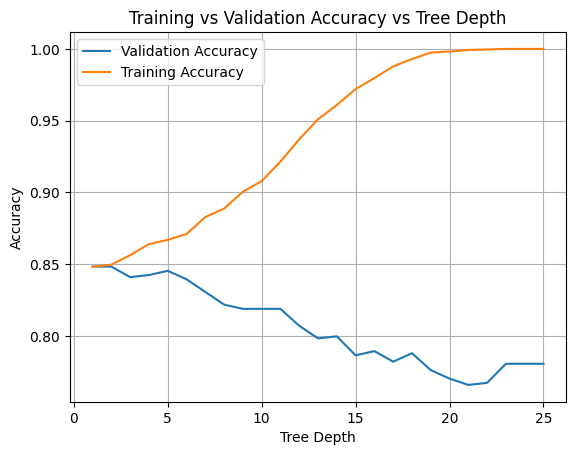

In [22]:
Val_acc = []
Train_acc = []

for d in range(1, 26):
  model = make_pipeline(SimpleImputer(), DecisionTreeClassifier(max_depth=d,random_state=42))
  model.fit(x_train, y_train)
  Val_acc.append(model.score(x_val, y_val))
  Train_acc.append(model.score(x_train, y_train))

#Now plot both lists
plt.plot(range(1, 26), Val_acc, label = "Validation Accuracy")
plt.plot(range(1, 26), Train_acc, label = "Training Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy vs Tree Depth")
plt.grid()
plt.legend()

In [23]:
over_sampler = RandomOverSampler(random_state=42)
x_train_over, y_train_over = over_sampler.fit_resample(x_train, y_train)

print("Original train shape:", x_train.shape)
print("Oversampled train shape:", x_train_over.shape)

Original train shape: (2713, 15)
Oversampled train shape: (4602, 15)


In [24]:
model2 = make_pipeline(SimpleImputer(), RandomForestClassifier())
print(model2)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('randomforestclassifier', RandomForestClassifier())])


In [25]:
cv_acc_scores = cross_val_score(model2, x_train_over, y_train_over, cv = 5, n_jobs=-1)
print(cv_acc_scores)
print("Mean CV Accuracy:", cv_acc_scores.mean())

[0.97502714 0.96525516 0.96847826 0.97934783 0.97717391]
Mean CV Accuracy: 0.973056460369164


In [26]:
params = {
    "simpleimputer__strategy": ["mean", "median"],
    "randomforestclassifier__n_estimators": [10, 100],
    "randomforestclassifier__max_depth": [2, 10, 30]
}

In [27]:
model_main = GridSearchCV(
    model2,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring="roc_auc"
)

In [28]:
model_main.fit(x_train_over, y_train_over)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [2, 10, 30],
                         'randomforestclassifier__n_estimators': [10, 100],
                         'simpleimputer__strategy': ['mean', 'median']},
             scoring='roc_auc', verbose=1)

In [29]:
cv_results = pd.DataFrame(model_main.cv_results_)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.031904,0.000785,0.007749,0.001760,2,10,mean,"{'randomforestclassifier__max_depth': 2, 'rand...",0.737822,0.731774,0.733183,0.735404,0.687888,0.725214,0.018776,11
1,0.035139,0.001820,0.006646,0.000269,2,10,median,"{'randomforestclassifier__max_depth': 2, 'rand...",0.741262,0.712027,0.725135,0.731694,0.707150,0.723454,0.012524,12
2,0.266482,0.049117,0.020715,0.007083,2,100,mean,"{'randomforestclassifier__max_depth': 2, 'rand...",0.755911,0.725821,0.740099,0.733698,0.709182,0.732942,0.015457,9
3,0.398316,0.062394,0.025190,0.005782,2,100,median,"{'randomforestclassifier__max_depth': 2, 'rand...",0.752421,0.719200,0.734390,0.737228,0.716101,0.731868,0.013165,10
4,0.107139,0.004198,0.015918,0.002505,10,10,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.944749,0.952683,0.943582,0.963790,0.965080,0.953977,0.009105,8
5,0.095683,0.017888,0.012319,0.002629,10,10,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.942724,0.955791,0.953417,0.968086,0.955685,0.955141,0.008068,7
6,0.586110,0.096229,0.022270,0.000979,10,100,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.968047,0.972531,0.972070,0.983998,0.976196,0.974568,0.005376,5
7,0.485001,0.006527,0.023197,0.000920,10,100,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.963034,0.972795,0.969386,0.985288,0.969457,0.971992,0.007361,6
8,0.071471,0.010720,0.008003,0.000139,30,10,mean,"{'randomforestclassifier__max_depth': 30, 'ran...",0.989809,0.996444,0.998729,0.999197,0.998826,0.996601,0.003532,3
9,0.067446,0.000957,0.008057,0.000202,30,10,median,"{'randomforestclassifier__max_depth': 30, 'ran...",0.988739,0.997906,0.995995,0.999586,0.997424,0.995930,0.003774,4


In [30]:
best_model = model_main.best_estimator_

test_score = best_model.score(x_test, y_test)
print("Test Score:", test_score)

Test Score: 0.8290094339622641


In [31]:
male = widgets.IntText(description="Male (0/1):")
age = widgets.IntText(description="Age:")
education = widgets.FloatText(description="Education:")
currentSmoker = widgets.IntText(description="Smoker (0/1):")
cigsPerDay = widgets.FloatText(description="Cigs/Day:")
BPMeds = widgets.IntText(description="BP Meds (0/1):")
prevalentStroke = widgets.IntText(description="Stroke (0/1):")
prevalentHyp = widgets.IntText(description="Hypertension (0/1):")
diabetes = widgets.IntText(description="Diabetes (0/1):")
totChol = widgets.FloatText(description="Cholesterol:")
sysBP = widgets.FloatText(description="Sys BP:")
diaBP = widgets.FloatText(description="Dia BP:")
BMI = widgets.FloatText(description="BMI:")
heartRate = widgets.FloatText(description="Heart Rate:")
glucose = widgets.FloatText(description="Glucose:")

predict_btn = widgets.Button(description="Predict CHD Risk")
output = widgets.Output()

In [32]:
def predict_chd(b):
    with output:
        output.clear_output()

        data = pd.DataFrame([{
            "male": male.value,
            "age": age.value,
            "education": education.value,
            "currentSmoker": currentSmoker.value,
            "cigsPerDay": cigsPerDay.value,
            "BPMeds": BPMeds.value,
            "prevalentStroke": prevalentStroke.value,
            "prevalentHyp": prevalentHyp.value,
            "diabetes": diabetes.value,
            "totChol": totChol.value,
            "sysBP": sysBP.value,
            "diaBP": diaBP.value,
            "BMI": BMI.value,
            "heartRate": heartRate.value,
            "glucose": glucose.value
        }])

        pred = best_model.predict(data)[0]

        if pred == 1:
            print("⚠ High Risk of CHD")
        else:
            print("✅ Low Risk of CHD")

In [33]:
predict_btn.on_click(predict_chd)

In [ ]:
display(
    male, age, education, currentSmoker, cigsPerDay,
    BPMeds, prevalentStroke, prevalentHyp, diabetes,
    totChol, sysBP, diaBP, BMI, heartRate, glucose,
    predict_btn, output
)

IntText(value=0, description='Male (0/1):')

IntText(value=0, description='Age:')

FloatText(value=0.0, description='Education:')

IntText(value=0, description='Smoker (0/1):')

FloatText(value=0.0, description='Cigs/Day:')

...

FloatText(value=0.0, description='BMI:')

FloatText(value=0.0, description='Heart Rate:')

FloatText(value=0.0, description='Glucose:')

Button(description='Predict CHD Risk', style=ButtonStyle())

Output()